# UTS Machine Learning - Medical Diagnosis (Classification)
Nama: Nurul Hasanah
NIM: 2411070044
Kelas: Reguler Pagi


In [10]:
!pip install wandb scikit-learn imbalanced-learn xgboost -q

In [11]:
import wandb
wandb.login()

True

In [12]:
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from imblearn.over_sampling import SMOTE
import seaborn as sns
import matplotlib.pyplot as plt


In [13]:
# Load dataset
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Handle imbalance
smote = SMOTE()
X_train, y_train = smote.fit_resample(X_train, y_train)

# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [14]:
def train_model(model, name):
    wandb.init(project="UTS-ML", name=name)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    cm = confusion_matrix(y_test, preds)

    wandb.log({"accuracy": acc, "f1": f1})

    sns.heatmap(cm, annot=True)
    plt.title(name)
    plt.show()

    wandb.finish()
    return acc, f1


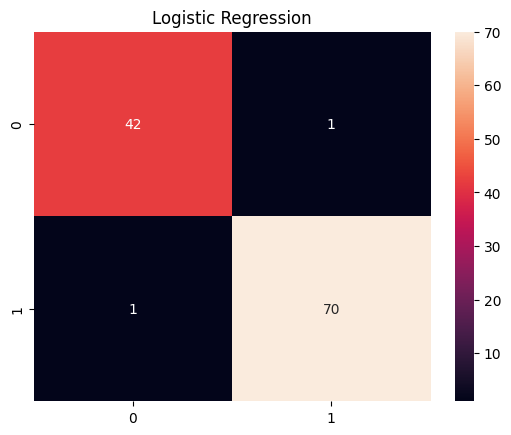

accuracy,▁
f1,▁
accuracy,0.98246
f1,0.98592


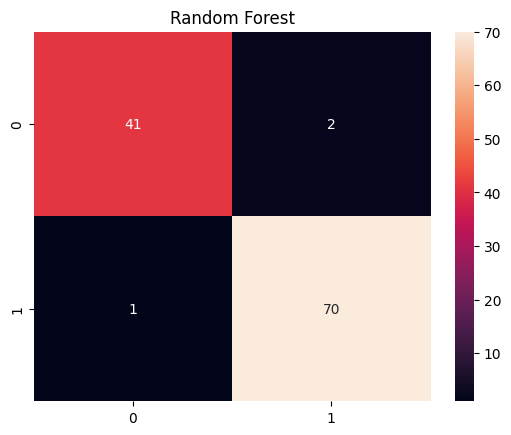

accuracy,▁
f1,▁
accuracy,0.97368
f1,0.97902


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [04:58:28] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


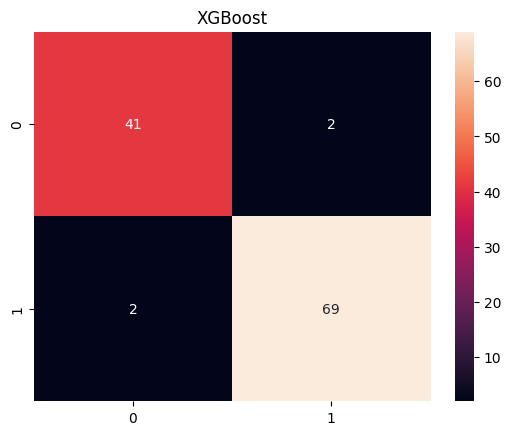

accuracy,▁
f1,▁
accuracy,0.96491
f1,0.97183


{'Logistic': (0.9824561403508771, 0.9859154929577465), 'RandomForest': (0.9736842105263158, 0.9790209790209791), 'XGBoost': (0.9649122807017544, 0.971830985915493)}


In [15]:
# Train models
results = {}

results['Logistic'] = train_model(LogisticRegression(), "Logistic Regression")
results['RandomForest'] = train_model(RandomForestClassifier(), "Random Forest")
results['XGBoost'] = train_model(XGBClassifier(use_label_encoder=False, eval_metric='logloss'), "XGBoost")

print(results)